In [6]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd

df = pd.read_excel(r"C:\Users\Shakil Ahmed\Downloads\archive (1)\Marketing Campaign Performance and ROI Dataset.xlsx")

df.head()

,Unnamed: 0,Unnamed: 1
0,NaN,NaN
1,Row Labels,Average of ROI %
2,NaN,2.445565
3,Email,7.403347
4,Paid Search,3.34591


In [8]:
df.shape

(10, 2)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  8 non-null      object
 1   Unnamed: 1  8 non-null      object
dtypes: object(2)
memory usage: 292.0+ bytes


In [10]:
df.columns.tolist()

['Unnamed: 0', 'Unnamed: 1']

In [11]:
pd.ExcelFile(r"C:\Users\Shakil Ahmed\Downloads\archive (1)\Marketing Campaign Performance and ROI Dataset.xlsx").sheet_names

['Sheet1', 'Sheet3', 'Sheet2', 'Marketing Campaign Performance ']

In [12]:
df = pd.read_excel(
    r"C:\Users\Shakil Ahmed\Downloads\archive (1)\Marketing Campaign Performance and ROI Dataset.xlsx",
    sheet_name="Marketing Campaign Performance "
)

df.head()

,Campaign_ID,Date,Marketing_channel,Spend,Clicks,Revenue,ROI %
0,CMP_1085,2023-09-22,Referral,3463.91,1993,18313.28,4.286881
1,CMP_1031,2023-11-10,Ppc,1272.77,1940,5454.00,3.285142
2,CMP_1081,2023-04-18,Paid Search,2141.78,1938,3340.12,0.559507
3,CMP_1086,2023-12-20,Email,2158.13,1932,3612.02,0.673680
4,CMP_1092,2023-04-25,Paid Search,3601.25,1925,9529.05,1.646040


In [13]:
df.isnull().sum()

Campaign_ID          0
Date                 0
Marketing_channel    5
Spend                0
Clicks               0
Revenue              0
ROI %                0
dtype: int64

In [14]:
df["Marketing_channel"] = df["Marketing_channel"].fillna("Unknown")

In [15]:
df.isnull().sum()

Campaign_ID          0
Date                 0
Marketing_channel    0
Spend                0
Clicks               0
Revenue              0
ROI %                0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.dtypes

Campaign_ID                  object
Date                 datetime64[ns]
Marketing_channel            object
Spend                       float64
Clicks                        int64
Revenue                     float64
ROI %                       float64
dtype: object

In [18]:
df["Date"] = pd.to_datetime(df["Date"])

In [19]:
df.dtypes

Campaign_ID                  object
Date                 datetime64[ns]
Marketing_channel            object
Spend                       float64
Clicks                        int64
Revenue                     float64
ROI %                       float64
dtype: object

In [20]:
df.describe()

,Date,Spend,Clicks,Revenue,ROI %
count,88,88.000000,88.000000,88.000000,88.000000
mean,2023-07-23 09:49:05.454545408,2469.949886,1030.556818,9926.120795,6.588810
min,2023-01-02 00:00:00,178.650000,92.000000,742.120000,-0.832564
25%,2023-04-23 06:00:00,1228.655000,538.750000,5420.267500,1.149045
50%,2023-08-16 00:00:00,2424.655000,1016.500000,9828.965000,2.938984
75%,2023-10-15 18:00:00,3693.897500,1582.500000,15248.220000,6.374517
max,2024-01-01 00:00:00,4961.890000,1993.000000,19299.420000,44.804926
std,NaN,1425.653332,574.173266,5571.553750,10.121291


In [21]:
df.groupby("Marketing_channel")["ROI %"].mean().sort_values(ascending=False)

Marketing_channel
Ppc             9.661175
Email           7.403347
Referral        7.374518
Social Media    5.961629
Paid Search     3.345910
Unknown         2.445565
Name: ROI %, dtype: float64

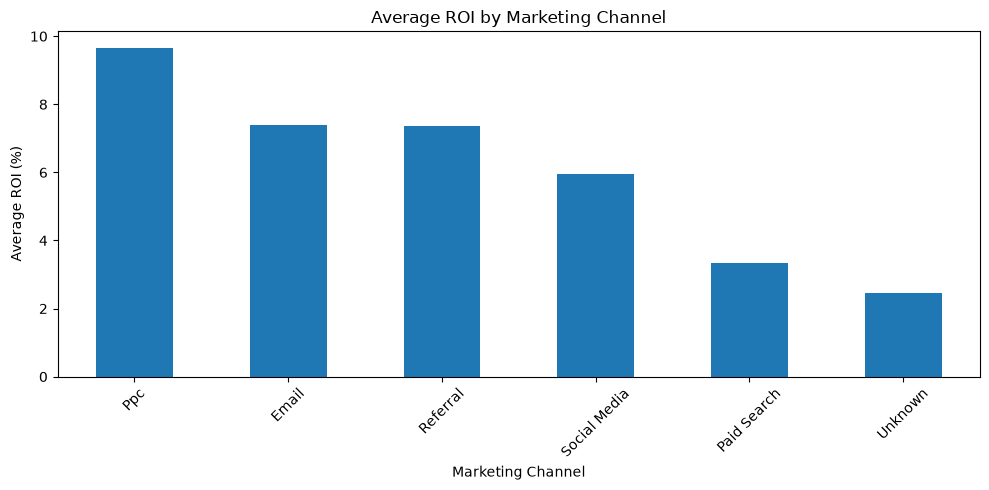

In [22]:
import matplotlib.pyplot as plt

roi_by_channel = df.groupby("Marketing_channel")["ROI %"].mean().sort_values(ascending=False)

roi_by_channel.plot(kind="bar", figsize=(10,5))

plt.title("Average ROI by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Average ROI (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
revenue_by_channel = df.groupby("Marketing_channel")["Revenue"].sum().sort_values(ascending=False)

revenue_by_channel

Marketing_channel
Ppc             236060.73
Social Media    187031.65
Paid Search     168458.37
Referral        148635.88
Email            98370.57
Unknown          34941.43
Name: Revenue, dtype: float64

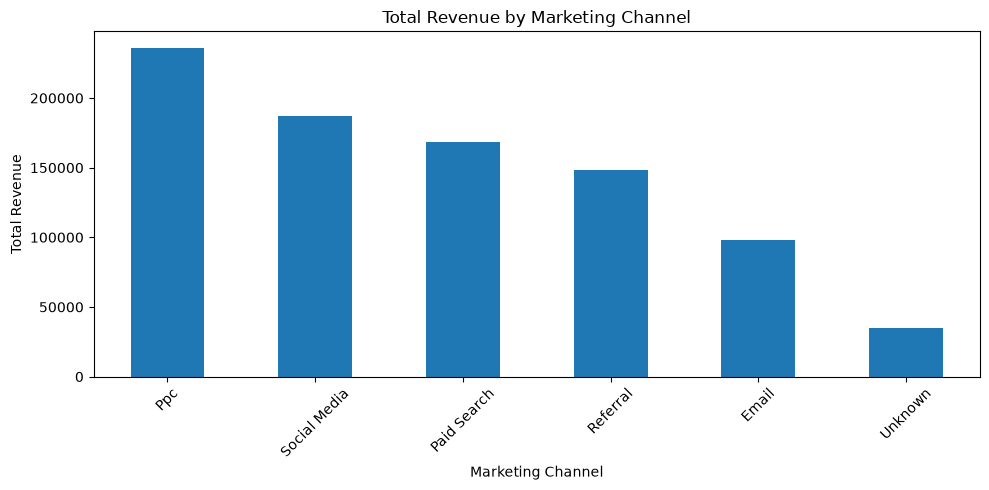

In [24]:
revenue_by_channel.plot(kind="bar", figsize=(10,5))

plt.title("Total Revenue by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
funnel = {
    "Total Spend": df["Spend"].sum(),
    "Total Clicks": df["Clicks"].sum(),
    "Total Revenue": df["Revenue"].sum()
}

funnel

{'Total Spend': np.float64(217355.58999999997),
 'Total Clicks': np.int64(90689),
 'Total Revenue': np.float64(873498.63)}

In [26]:
ctr = (df["Clicks"].sum() / df["Spend"].sum()) * 100
roas = df["Revenue"].sum() / df["Spend"].sum()

print("CTR:", round(ctr, 2), "%")
print("ROAS:", round(roas, 2))

CTR: 41.72 %
ROAS: 4.02


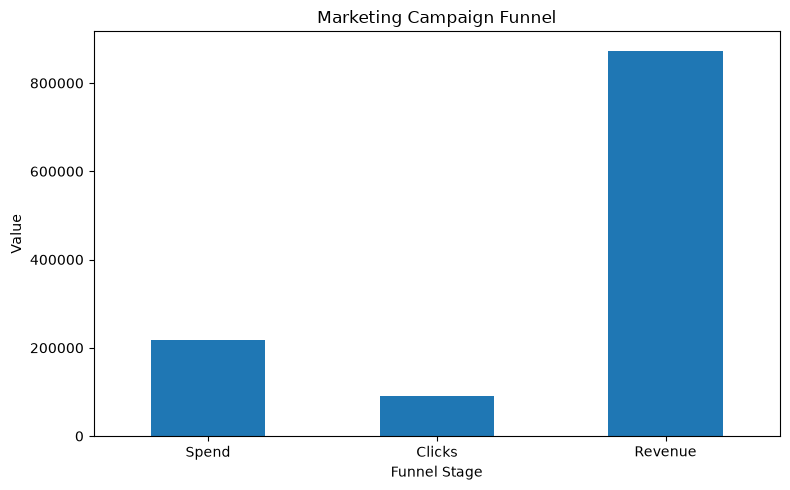

In [27]:
funnel_data = pd.Series({
    "Spend": df["Spend"].sum(),
    "Clicks": df["Clicks"].sum(),
    "Revenue": df["Revenue"].sum()
})

funnel_data.plot(kind="bar", figsize=(8, 5))

plt.title("Marketing Campaign Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

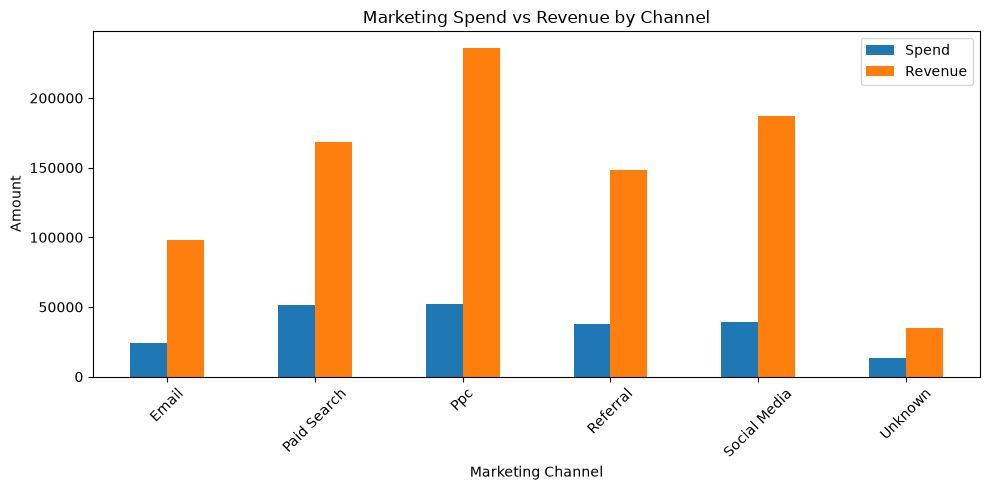

In [28]:
channel_performance = df.groupby("Marketing_channel")[["Spend", "Revenue"]].sum()

channel_performance.plot(kind="bar", figsize=(10, 5))

plt.title("Marketing Spend vs Revenue by Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend(["Spend", "Revenue"])
plt.tight_layout()
plt.show()

In [29]:
summary = df.groupby("Marketing_channel").agg(
    Total_Spend=("Spend", "sum"),
    Total_Revenue=("Revenue", "sum"),
    Average_ROI=("ROI %", "mean")
).sort_values("Average_ROI", ascending=False)

summary

,Total_Spend,Total_Revenue,Average_ROI
Marketing_channel,,,
Ppc,52138.95,236060.73,9.661175
Email,23795.44,98370.57,7.403347
Referral,37664.32,148635.88,7.374518
Social Media,39045.29,187031.65,5.961629
Paid Search,51349.04,168458.37,3.345910
Unknown,13362.55,34941.43,2.445565


In [30]:
df.to_csv("Marketing_Campaign_Cleaned.csv", index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!


In [31]:
channel_roi = df.groupby("Marketing_channel").agg(
    Total_Spend=("Spend", "sum"),
    Total_Revenue=("Revenue", "sum")
)

channel_roi["ROI (%)"] = (
    (channel_roi["Total_Revenue"] - channel_roi["Total_Spend"])
    / channel_roi["Total_Spend"] * 100
)

channel_roi = channel_roi.sort_values("ROI (%)", ascending=False)

channel_roi

,Total_Spend,Total_Revenue,ROI (%)
Marketing_channel,,,
Social Media,39045.29,187031.65,379.012065
Ppc,52138.95,236060.73,352.753134
Email,23795.44,98370.57,313.400929
Referral,37664.32,148635.88,294.633117
Paid Search,51349.04,168458.37,228.065276
Unknown,13362.55,34941.43,161.487740


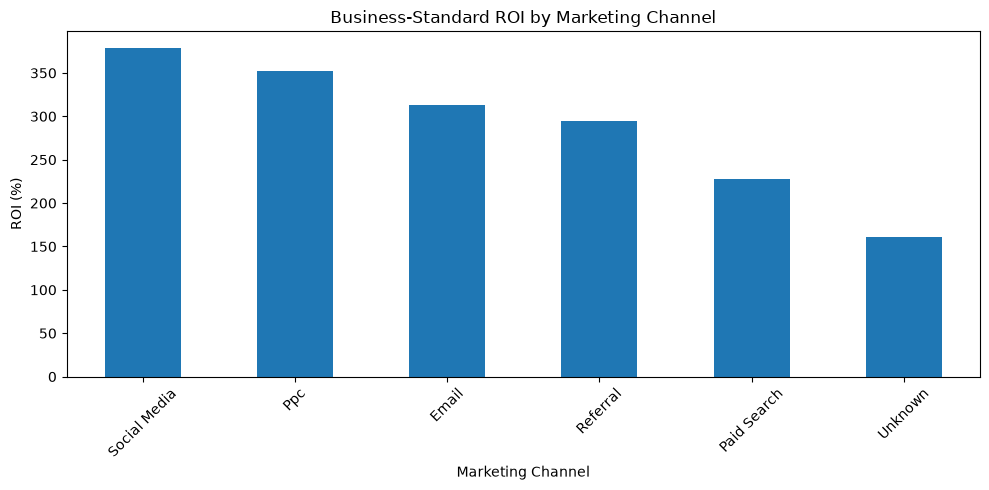

In [32]:
channel_roi["ROI (%)"].plot(kind="bar", figsize=(10,5))

plt.title("Business-Standard ROI by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("ROI (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()